In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg

In [6]:
dat = pd.read_csv('Data/cleaned_data.csv')
dat.head()

,time,survey_date,last_4_digits_uid,last_name,enrolled_course,major,minor,gender,gender_self_described,ethnicity,...,scenario_1,scenario_1_reason,scenario_2,scenario_2_reason,scenario_3,scenario_3_reason,scenario_4,scenario_4_reason,scenario_5,scenario_5_reason
0,1/29/2026 15:02:43,1/29/2026,532,Whitney,ELTS120XP,Global studies,"Food studies, global health",Man,NaN,White,...,I would encourage my teammate to discuss the s...,Before acting directly on it I would go to th...,"Given the circumstances, it would be better no...",I would be unsure what to say or do,I would take some form of action related to ho...,I would take action. Ask questions.,"Given the circumstances, what would you advise...","I’m not sure if I read this correctly, but it ...",Move to zoom workshops,I think a lot of barriers come up around findi...
1,1/29/2026 22:54:03,1/29/2026,7824,Sleeper,ENGCOMP130DX,Public Affairs,"Professional Writing, Environmental Systems & ...",Woman,NaN,Hispanic/Latinx,...,I would encourage my teammate to discuss the s...,I would definitely take a stand and respond to...,I would first discuss the situation with my in...,I would ask the instructor because they probab...,I would suggest discussing the ethical concern...,I would definitely consult the instructor. Giv...,"Given the circumstances, what would you advise...",I would advise my friend to choose Job B. This...,Move to zoom workshops,I would say move the workshops to zoom. This w...
2,1/30/2026 12:26:40,1/30/2026,3402,Owen,CESC 191AX,Political Science,CESC,Woman,NaN,White,...,I would encourage my teammate to discuss the s...,"School is very important, but I would feel a s...",I would first discuss the situation with my in...,I would like to get permission first to speak ...,I would suggest discussing the ethical concern...,The results don’t have to necessarily be publi...,"Given the circumstances, what would you advise...",I would advise my friend that they may feel mo...,Continue with in-person workshops,In-person meetings are much more valuable ways...
3,1/30/2026 13:24:01,1/30/2026,4689,Wenn,CESC191AX,Study of Religion,Community Engagement & Social Change,Woman,NaN,White,...,I would encourage my teammate to discuss the s...,While it is important to acknowledge that acad...,I would first discuss the situation with my in...,Because the community hasn't asked me to speak...,"Given the circumstances, I would agree it is b...","Ethics, consent, and correct interpretation of...","Given the circumstances, what would you advise...",I think the experience of working with both in...,Move to zoom workshops,Zoom meetings are more convenient than in-pers...
4,1/30/2026 13:30:49,1/30/2026,2809,Sobel,CESC 191AX,Political Science,CESC,Woman,NaN,White,...,I would encourage my teammate to discuss the s...,I would tell my partner to explain how they ar...,I would first discuss the situation with my in...,"if you want to speak up, you should help in an...","Given the circumstances, I would agree it is b...","the organization is who you are serving, so if...","Given the circumstances, what would you advise...",More opportunities to expand the scope of the ...,Continue with in-person workshops,Offer a hybrid option where families that cann...


In [7]:
dat.columns

Index(['time', 'survey_date', 'last_4_digits_uid', 'last_name',
       'enrolled_course', 'major', 'minor', 'gender', 'gender_self_described',
       'ethnicity', 'first_gen_college', 'mother_education_level',
       'father_education_level', 'transfer_student', 'gpa_range', 'xp_courses',
       'xp_motivation', 'major_minor_motivation', 'belonging_rate',
       'hesitation_to_participate', 'respected_by_group',
       'perspective_inclusion', 'mistake_safety_in_group',
       'input_not_considered', 'comfort_asking_questions', 'meaningful_role',
       'non_valuable_contribution', 'community_work_valuable',
       'comfortable_sharing_ideas', 'feel_ignored',
       'community_partners_inclusion', 'community_partners_understanding',
       'lack_of_interaction_with_partners', 'do_patners_help', 'scenario_1',
       'scenario_1_reason', 'scenario_2', 'scenario_2_reason', 'scenario_3',
       'scenario_3_reason', 'scenario_4', 'scenario_4_reason', 'scenario_5',
       'scenario_5_reason'

In [ ]:
likert_cols = [
    'hesitation_to_participate',
    'respected_by_group',
    'perspective_inclusion',
    'mistake_safety_in_group',
    'input_not_considered',
    'comfort_asking_questions',
    'meaningful_role',
    'non_valuable_contribution',
    'community_work_valuable',
    'comfortable_sharing_ideas',
    'feel_ignored',
    'community_partners_inclusion',
    'community_partners_understanding',
    'lack_of_interaction_with_partners',
    'do_patners_help'
]

neg_items = [
    'hesitation_to_participate', 'input_not_considered', 
    'non_valuable_contribution', 'feel_ignored', 'lack_of_interaction_with_partners'
]

In [12]:
for item in neg_items:
    dat[item + '_rev'] = 6 - dat[item]

final_likert_cols = [col if col not in neg_items else col + '_rev' for col in likert_cols]

df_likert = dat[final_likert_cols].dropna()

In [14]:
df_likert['total_score'] = df_likert.sum(axis=1)

item_total_corrs = df_likert[final_likert_cols].apply(lambda x: x.corr(df_likert['total_score']))
print("--- Item-Total Correlations ---")
print(item_total_corrs)
print("\n")

--- Item-Total Correlations ---
hesitation_to_participate_rev            0.298783
respected_by_group                       0.452669
perspective_inclusion                    0.666395
mistake_safety_in_group                  0.571236
input_not_considered_rev                 0.234743
comfort_asking_questions                 0.543291
meaningful_role                          0.656563
non_valuable_contribution_rev            0.640737
community_work_valuable                  0.166274
comfortable_sharing_ideas                0.565199
feel_ignored_rev                         0.285176
community_partners_inclusion             0.276470
community_partners_understanding         0.525079
lack_of_interaction_with_partners_rev    0.577010
do_patners_help                          0.557314
dtype: float64




In [17]:
alpha, ci = pg.cronbach_alpha(data=df_likert[final_likert_cols])
print(f"Overall Cronbach's Alpha: {alpha:.3f} (95% CI: {ci})")
print("\n")

Overall Cronbach's Alpha: 0.722 (95% CI: [0.552 0.848])




In [19]:
item_rel = pg.cronbach_alpha(data=df_likert[final_likert_cols])
corrected_item_total_corrs = {}
alpha_if_deleted = {}

for item in final_likert_cols:
    score_without_item = df_likert['total_score'] - df_likert[item]
    
    # Pearson correlation
    corr = df_likert[item].corr(score_without_item)
    corrected_item_total_corrs[item] = corr
    
    # Item del alpha
    df_subset = df_likert[final_likert_cols].drop(columns=[item])
    
    alpha_val, ci = pg.cronbach_alpha(data=df_subset)
    alpha_if_deleted[item] = alpha_val

item_analysis_df = pd.DataFrame({
    'Corrected_Item_Total_Corr': pd.Series(corrected_item_total_corrs),
    'Alpha_If_Deleted': pd.Series(alpha_if_deleted)
})

item_analysis_df = item_analysis_df.sort_values(by='Alpha_If_Deleted', ascending=False)

print("--- Item Reliability Analysis ---")
print(item_analysis_df)

--- Item Reliability Analysis ---
                                       Corrected_Item_Total_Corr  \
input_not_considered_rev                                0.040416   
hesitation_to_participate_rev                           0.134164   
community_work_valuable                                 0.055089   
community_partners_inclusion                            0.146082   
feel_ignored_rev                                        0.254241   
respected_by_group                                      0.295638   
comfort_asking_questions                                0.383067   
community_partners_understanding                        0.419570   
do_patners_help                                         0.437301   
comfortable_sharing_ideas                               0.464198   
mistake_safety_in_group                                 0.436697   
lack_of_interaction_with_partners_rev                   0.441243   
meaningful_role                                         0.591011   
non_valuable_c

In [20]:
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

In [21]:
data_for_efa = df_likert[final_likert_cols]
chi_square_value, p_value = calculate_bartlett_sphericity(data_for_efa)
print(f"Bartlett's Test p-value: {p_value:.4f}")

Bartlett's Test p-value: 0.0000


In [22]:
kmo_all, kmo_model = calculate_kmo(data_for_efa)
print(f"KMO Model Value: {kmo_model:.3f}")

KMO Model Value: 0.427


/opt/anaconda3/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [23]:
import seaborn as sns

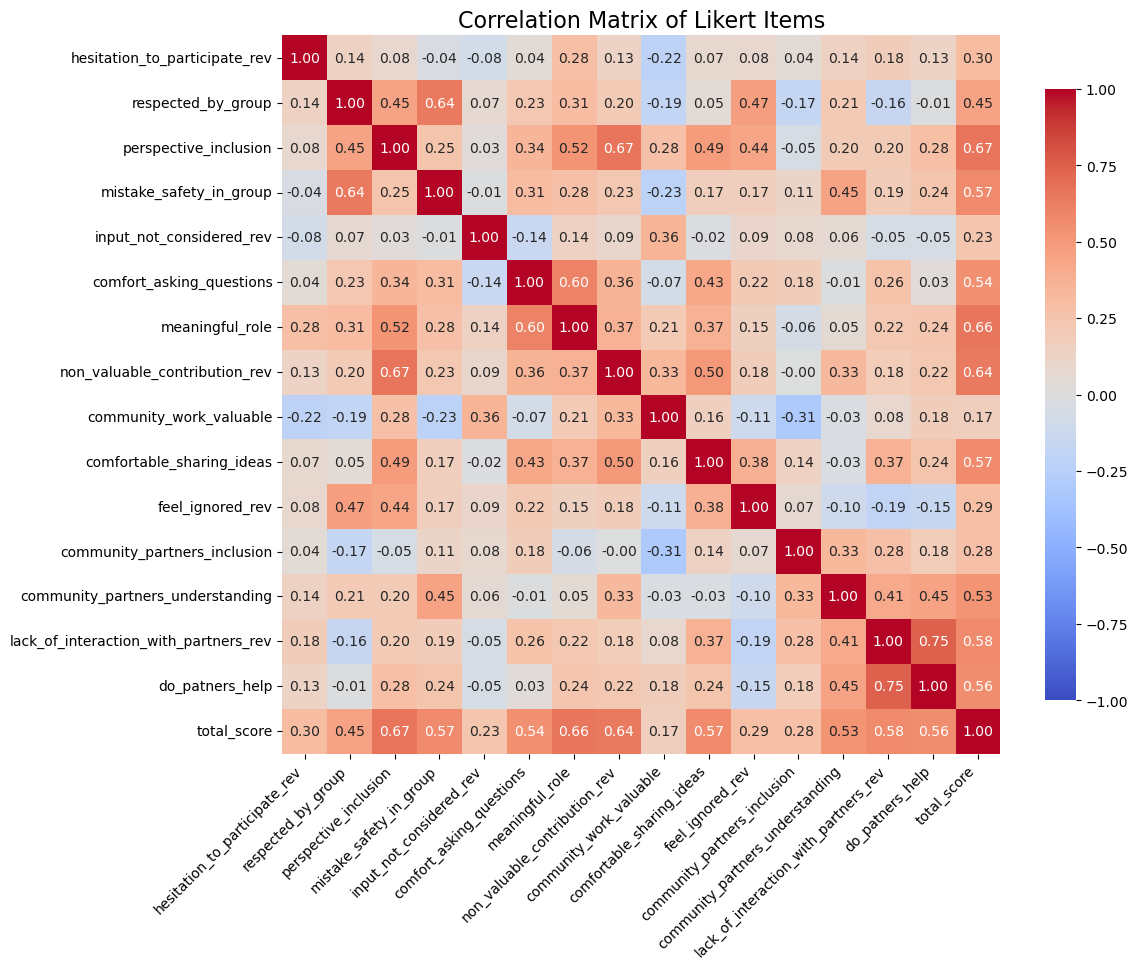

In [24]:
corr_matrix = df_likert.corr()

plt.figure(figsize=(12, 10))
# Using 'coolwarm' so high positive correlations are dark red, and negative are dark blue
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, 
            square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of Likert Items", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
dat.fillna(0, inplace=True)

In [35]:
dat['belonging_rate'].unique()

array(['About the same', 'Higher'], dtype=object)

In [32]:
for item in neg_items:
    dat[f"{item}_rev"] = 6 - dat[item]

In [33]:
belonging_mapping = {
    'Lower': 1, 
    'About the same': 2, 
    'Higher': 3
}

dat['belonging_rate_num'] = dat['belonging_rate'].map(belonging_mapping)


--- RQ1: Student Connection to Community Engagement ---
count    45.000000
mean      3.725926
std       0.679010
min       1.666667
25%       3.666667
50%       4.000000
75%       4.333333
max       4.333333
Name: connection_score, dtype: float64


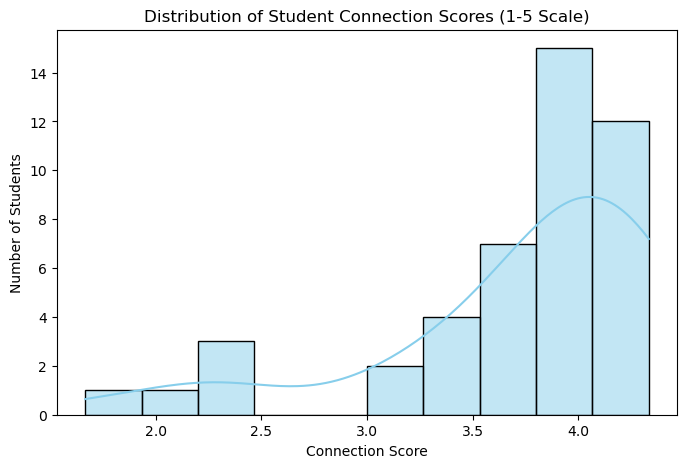

In [37]:
# Theme 1: Connection & Meaningful Role (RQ1, RQ3)
dat['connection_score'] = dat[['meaningful_role', 'community_work_valuable', 'belonging_rate_num']].mean(axis=1)

# Theme 2: Valuing Community Partners (RQ5)
dat['partner_value_score'] = dat[[
    'community_partners_inclusion', 
    'community_partners_understanding', 
    'do_patners_help',
    'lack_of_interaction_with_partners_rev'
]].mean(axis=1) # Add 'lack_of_interaction_with_partners_rev' if you reverse-coded it

# Theme 3: Group Inclusivity / Psychological Safety (RQ4)
dat['group_safety_score'] = dat[[
    'respected_by_group', 'perspective_inclusion', 'mistake_safety_in_group', 
    'comfort_asking_questions', 'comfortable_sharing_ideas'
]].mean(axis=1)


# --- RQ1: To what extent do students feel connected to their community engagement experiences? ---
print("--- RQ1: Student Connection to Community Engagement ---")
print(dat['connection_score'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(dat['connection_score'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Student Connection Scores (1-5 Scale)')
plt.xlabel('Connection Score')
plt.ylabel('Number of Students')
plt.show()


--- RQ2/3/4: Value of Community Work vs. Past Experience ---


/var/folders/cw/cx368b590mb_cg5tg17mvqv40000gn/T/ipykernel_55122/1578476700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dat, x='xp_courses', y='community_work_valuable', palette='Set2')


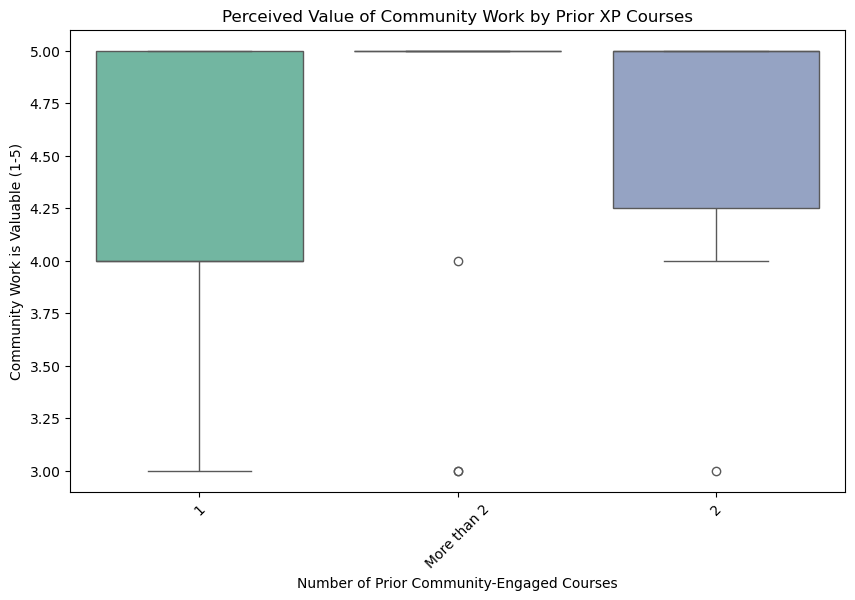

In [40]:
print("\n--- RQ2/3/4: Value of Community Work vs. Past Experience ---")
# Let's see if students with more past courses value the work more
plt.figure(figsize=(10, 6))
sns.boxplot(data=dat, x='xp_courses', y='community_work_valuable', palette='Set2')
plt.title('Perceived Value of Community Work by Prior XP Courses')
plt.xlabel('Number of Prior Community-Engaged Courses')
plt.ylabel('Community Work is Valuable (1-5)')
plt.xticks(rotation=45)
plt.show()

In [41]:
print("\n--- RQ5: Valuing Community Partners ---")
print(dat['partner_value_score'].describe())


--- RQ5: Valuing Community Partners ---
count    45.000000
mean      4.177778
std       0.857159
min       2.000000
25%       3.750000
50%       4.500000
75%       4.750000
max       5.250000
Name: partner_value_score, dtype: float64



--- RQ7: Differences by Ethnicity and Gender ---
Mean Scores and Sample Sizes by Ethnicity and Gender:
                                             connection_score        \
                                                         mean count   
ethnicity                  gender                                     
0                          0                             4.00     2   
                           Woman                         3.67     1   
Asian / Pacific Islander   Man                           3.00     1   
                           Prefer not to Say             3.67     2   
                           Woman                         3.78     9   
Hispanic/Latinx            Woman                         4.02    14   
Multiple Ethnicity / Other Woman                         4.00     2   
White                      Man                           3.33     2   
                           Woman                         3.39    12   

                                           

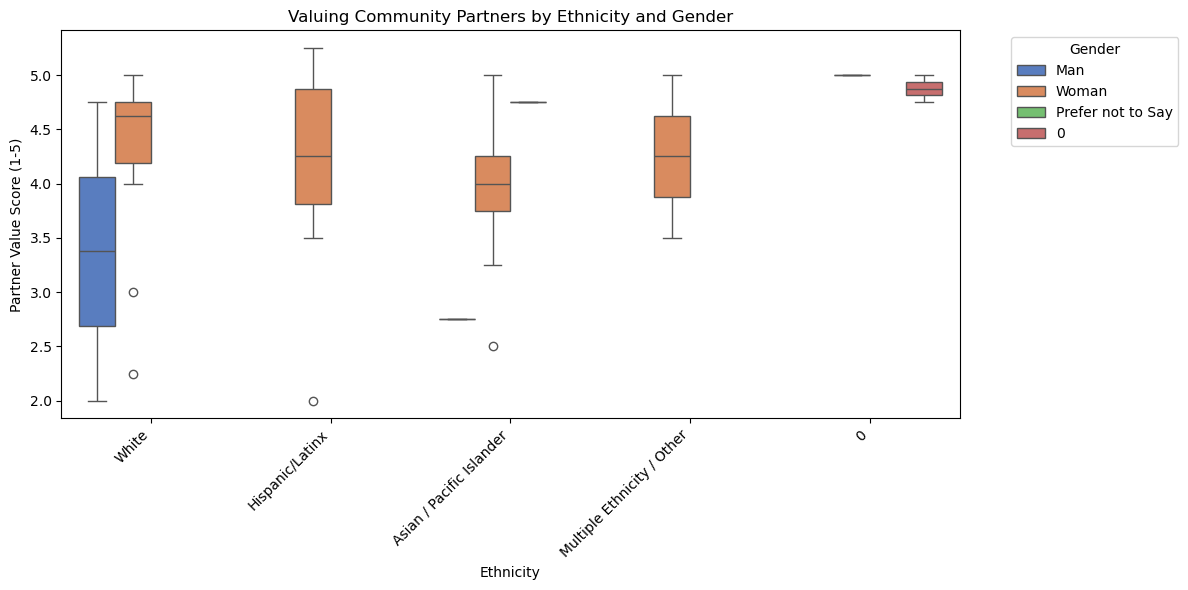

In [43]:
# --- RQ7: Differences based on Race/Ethnicity and Gender ---
print("\n--- RQ7: Differences by Ethnicity and Gender ---")

# Calculate concrete descriptive statistics for the groups
eth_gender_stats = dat.groupby(['ethnicity', 'gender'])[['connection_score', 'partner_value_score']].agg(['mean', 'count']).round(2)
print("Mean Scores and Sample Sizes by Ethnicity and Gender:")
print(eth_gender_stats)

# Visualizing differences by Ethnicity
plt.figure(figsize=(12, 6))
sns.boxplot(data=dat, x='ethnicity', y='partner_value_score', hue='gender', palette='muted')
plt.title('Valuing Community Partners by Ethnicity and Gender')
plt.xlabel('Ethnicity')
plt.ylabel('Partner Value Score (1-5)')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()